In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

%matplotlib inline

In [2]:
# 一个简单输入序列
x_seq = np.array([0.2, 0.8, -0.4, 0.6, 1.0, -0.2, 0.4, 0.9], dtype=float)

# RNN 参数（手动设置，便于教学）
Wx = 0.9   # 输入 -> 隐状态
Wh = 0.7   # 上一个隐状态 -> 当前隐状态
bh = 0.1   # 隐藏层偏置

Wy = 1.2   # 隐状态 -> 输出
by = -0.05 # 输出层偏置

print("x_seq =", x_seq)
print("Wx, Wh, bh, Wy, by =", Wx, Wh, bh, Wy, by)

x_seq = [ 0.2  0.8 -0.4  0.6  1.  -0.2  0.4  0.9]
Wx, Wh, bh, Wy, by = 0.9 0.7 0.1 1.2 -0.05


In [3]:
a_vals = []
h_vals = []
y_vals = []

h_prev = 0.0

for x_t in x_seq:
    # a_t = Wx*x_t + Wh*h_(t-1) + bh
    a_t = Wx * x_t + Wh * h_prev + bh
    
    # h_t = tanh(a_t)
    h_t = np.tanh(a_t)
    
    # y_t = Wy*h_t + by
    y_t = Wy * h_t + by
    
    a_vals.append(a_t)
    h_vals.append(h_t)
    y_vals.append(y_t)
    
    h_prev = h_t

a_vals = np.array(a_vals)
h_vals = np.array(h_vals)
y_vals = np.array(y_vals)

print("a_t =", np.round(a_vals, 3))
print("h_t =", np.round(h_vals, 3))
print("y_t =", np.round(y_vals, 3))

a_t = [0.28  1.011 0.276 0.829 1.476 0.55  0.811 1.379]
h_t = [0.273 0.766 0.27  0.68  0.901 0.501 0.67  0.881]
y_t = [0.277 0.869 0.273 0.766 1.031 0.551 0.754 1.007]


In [4]:
print(" t      x_t      a_t      h_t      y_t")
print("-" * 40)

for t in range(len(x_seq)):
    print(f"{t+1:<3d}   {x_seq[t]:>6.2f}   {a_vals[t]:>6.2f}   {h_vals[t]:>6.2f}   {y_vals[t]:>6.2f}")

 t      x_t      a_t      h_t      y_t
----------------------------------------
1       0.20     0.28     0.27     0.28
2       0.80     1.01     0.77     0.87
3      -0.40     0.28     0.27     0.27
4       0.60     0.83     0.68     0.77
5       1.00     1.48     0.90     1.03
6      -0.20     0.55     0.50     0.55
7       0.40     0.81     0.67     0.75
8       0.90     1.38     0.88     1.01


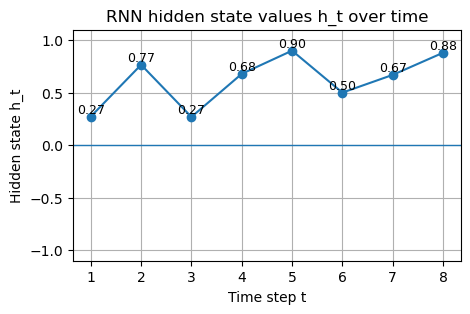

In [6]:
plt.figure(figsize=(5, 3))
plt.plot(np.arange(1, len(h_vals) + 1), h_vals, marker='o')

for i, v in enumerate(h_vals, start=1):
    if v >= 0:
        plt.text(i, v + 0.03, f"{v:.2f}", ha='center', fontsize=9)
    else:
        plt.text(i, v - 0.08, f"{v:.2f}", ha='center', fontsize=9)

plt.axhline(0, linewidth=1)
plt.ylim(-1.1, 1.1)
plt.xticks(np.arange(1, len(h_vals) + 1))
plt.xlabel("Time step t")
plt.ylabel("Hidden state h_t")
plt.title("RNN hidden state values h_t over time")
plt.grid(True)
plt.show()

In [7]:
print("解释：")
print("1. h_t 是当前时间步的隐藏状态，也可以理解为当前的“记忆”。")
print("2. h_t 不仅受当前输入 x_t 影响，还受上一步 h_(t-1) 影响。")
print("3. 所以 h_t 是带有历史信息的，不是独立的。")

解释：
1. h_t 是当前时间步的隐藏状态，也可以理解为当前的“记忆”。
2. h_t 不仅受当前输入 x_t 影响，还受上一步 h_(t-1) 影响。
3. 所以 h_t 是带有历史信息的，不是独立的。


In [8]:
# 为了演示反向传播，这里假设 target 全是 0
target = np.zeros_like(y_vals)

# 对于 MSE: dL/dy_t = y_t - target_t
dy_vals = y_vals - target

print("target =", target)
print("dy =", np.round(dy_vals, 3))

target = [0. 0. 0. 0. 0. 0. 0. 0.]
dy = [0.277 0.869 0.273 0.766 1.031 0.551 0.754 1.007]


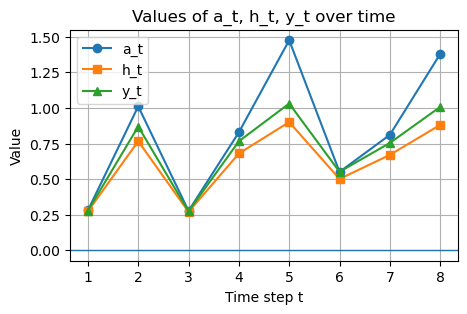

In [10]:
t_axis = np.arange(1, len(x_seq) + 1)

plt.figure(figsize=(5, 3))
plt.plot(t_axis, a_vals, marker='o', label='a_t')
plt.plot(t_axis, h_vals, marker='s', label='h_t')
plt.plot(t_axis, y_vals, marker='^', label='y_t')

plt.axhline(0, linewidth=1)
plt.xlabel("Time step t")
plt.ylabel("Value")
plt.title("Values of a_t, h_t, y_t over time")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
def draw_node(ax, x, y, label, value_text="", fc="white", ec="black", radius=0.45):
    circle = plt.Circle((x, y), radius, facecolor=fc, edgecolor=ec, linewidth=2)
    ax.add_patch(circle)
    ax.text(x, y + 0.03, label, ha="center", va="center", fontsize=18)
    if value_text:
        ax.text(x, y - 0.95, value_text, ha="center", va="center", fontsize=11)


def draw_arrow(ax, x1, y1, x2, y2, text="", color="black", lw=2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=lw, color=color, shrinkA=12, shrinkB=12)
    )
    if text:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.35, text,
                ha="center", va="center", fontsize=12, color=color)

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))

# 固定节点位置
pos = {
    "a": (2.0, 2.5),
    "h": (5.0, 2.5),
    "y": (8.0, 2.5),
    "loss": (8.0, 4.5),
}

T = len(x_seq)

def update(frame):
    ax.clear()
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis("off")
    
    t = frame % T
    phase = (frame // T) % 4
    # phase:
    # 0 -> 高亮 a_t
    # 1 -> 高亮 h_t
    # 2 -> 高亮 y_t
    # 3 -> 画 backward gradient
    
    ax.text(5, 5.7, "RNN: a → h → y and gradient flow", ha="center", fontsize=20)
    ax.text(
        5, 5.25,
        f"time step t = {t+1}    x_t={x_seq[t]:.2f},  a_t={a_vals[t]:.2f},  h_t={h_vals[t]:.2f},  y_t={y_vals[t]:.2f}",
        ha="center", fontsize=12
    )
    
    ax.text(1.0, 0.8, r"$a_t = W_x x_t + W_h h_{t-1} + b_h$", fontsize=14)
    ax.text(4.5, 0.8, r"$h_t = \tanh(a_t)$", fontsize=14)
    ax.text(6.8, 0.8, r"$y_t = W_y h_t + b_y$", fontsize=14)
    
    a_fc = "#cfe8ff" if phase == 0 else "white"
    h_fc = "#d9f2d9" if phase == 1 else "white"
    y_fc = "#ffe5b4" if phase == 2 else "white"
    l_fc = "#f5d0d0" if phase == 3 else "white"
    
    draw_node(ax, *pos["a"], r"$a_t$", f"value = {a_vals[t]:.2f}", fc=a_fc)
    draw_node(ax, *pos["h"], r"$h_t$", f"value = {h_vals[t]:.2f}", fc=h_fc)
    draw_node(ax, *pos["y"], r"$y_t$", f"value = {y_vals[t]:.2f}", fc=y_fc)
    draw_node(ax, *pos["loss"], r"$L_t$", f"dy = {dy_vals[t]:.2f}", fc=l_fc)
    
    # 前向箭头
    draw_arrow(ax, pos["a"][0] + 0.45, pos["a"][1], pos["h"][0] - 0.45, pos["h"][1],
               text="tanh", color="#1f77b4" if phase == 0 else "black", lw=3 if phase == 0 else 2)
    draw_arrow(ax, pos["h"][0] + 0.45, pos["h"][1], pos["y"][0] - 0.45, pos["y"][1],
               text=r"$W_y$", color="#2ca02c" if phase == 1 else "black", lw=3 if phase == 1 else 2)
    draw_arrow(ax, pos["y"][0], pos["y"][1] + 0.45, pos["loss"][0], pos["loss"][1] - 0.45,
               text="loss", color="#ff7f0e" if phase == 2 else "black", lw=3 if phase == 2 else 2)
    
    # 反向梯度
    if phase == 3:
        draw_arrow(ax, pos["loss"][0] + 0.8, pos["loss"][1] - 0.45, pos["y"][0] + 0.8, pos["y"][1] + 0.45,
                   text=r"$\partial L/\partial y_t$", color="red", lw=3)
        draw_arrow(ax, pos["y"][0] - 0.45, pos["y"][1] - 0.6, pos["h"][0] + 0.45, pos["h"][1] - 0.6,
                   text=r"$\partial L/\partial h_t$", color="red", lw=3)
        draw_arrow(ax, pos["h"][0] - 0.45, pos["h"][1]-0.6, pos["a"][0] + 0.45, pos["a"][1]-0.6,
                   text=r"$\partial L/\partial a_t$", color="red", lw=3)
        ax.text(5, 4.15, r"Backward: $L_t \rightarrow y_t \rightarrow h_t \rightarrow a_t$",
                color="red", ha="center", fontsize=13)
    
    messages = [
        "Phase 1: compute a_t first (linear combination before activation)",
        "Phase 2: pass a_t through tanh to get h_t (hidden state / memory)",
        "Phase 3: map h_t to y_t (output)",
        "Phase 4: gradients flow backward from L_t to y_t to h_t to a_t",
    ]
    ax.text(5, 0.25, messages[phase], ha="center", fontsize=12)

ani = FuncAnimation(fig, update, frames=T * 4, interval=900)
plt.close(fig)

In [46]:
from IPython.display import HTML

HTML(ani.to_jshtml())